In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("train.csv")
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [15]:
df.isnull().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64

In [4]:
print(df)

            id   age  daily_screen_time_hours  social_media_hours  \
0            0  24.0                      NaN                1.83   
1            1  19.0                     5.97                1.08   
2            2  18.0                     5.09                 NaN   
3            3  21.0                     6.42                1.26   
4            4  26.0                    11.20                1.87   
...        ...   ...                      ...                 ...   
691364  691364  22.0                    10.78                3.25   
691365  691365  20.0                     3.45                1.86   
691366  691366   NaN                      NaN                 NaN   
691367  691367  22.0                    11.78                3.69   
691368  691368  21.0                     5.64                1.03   

        gaming_hours  work_study_hours  sleep_hours  notifications_per_day  \
0               1.59              2.11         7.46                  122.0   
1              

In [5]:
columns=df.columns
print(columns)

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='str')


In [6]:
for x in ['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'] :
    df[x]=df[x].fillna(df[x].mean().round(1))

In [21]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,7.60,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,1,0,1
1,1,19.0,5.97,1.08,1.50,3.03,8.22,76.0,19.0,9.50,0,1,0,0
2,2,18.0,5.09,2.50,1.50,2.40,6.25,134.0,60.0,7.47,0,0,1,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0,0,1,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,145.9,102.6,13.39,0,1,0,1


In [8]:
df["gender"].value_counts()

gender
Male      223662
Female    221595
Other     217078
Name: count, dtype: int64

In [9]:
#scale the dataset 
#fill the null values
print(df["addicted_label"].value_counts())

addicted_label
1    490474
0    200895
Name: count, dtype: int64


In [10]:
#fill the null values
df.to_csv("dataset_cleaned.csv",index=False)

In [11]:
df["gender"]=df["gender"].fillna("Male")

In [12]:
df["stress_level"]=df["stress_level"].fillna("High")

In [13]:
df["academic_work_impact"]=df["academic_work_impact"].fillna("Yes")

In [19]:
df["gender"]=df["gender"].apply(lambda x:1 if x=="Male" else(2 if x=="Female" else 0))

In [20]:
df["stress_level"]=df["stress_level"].apply(lambda x:1 if x=="Medium" else(2 if x=="High" else 0))
df["academic_work_impact"]=df["academic_work_impact"].apply(lambda x:1 if x=="Yes" else 0)

<Axes: >

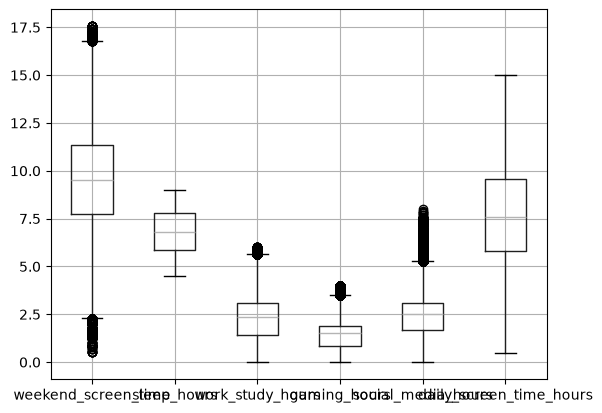

In [27]:
df[["weekend_screen_time","sleep_hours","work_study_hours","gaming_hours","social_media_hours","daily_screen_time_hours"]].boxplot()